In [135]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import re

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# convert categorical values to numberic values
from sklearn.preprocessing import LabelEncoder

#feature scaling
from sklearn.preprocessing import StandardScaler

# for trainning test data
from sklearn.model_selection import train_test_split

# For Building ML Model
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# for accuracy comparison
# for classification report
# Evaluation
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, roc_auc_score, roc_curve,
                              classification_report, ConfusionMatrixDisplay)

# to verify the stability ot ot increase the reliability of the model
from sklearn.model_selection import cross_val_score

from sklearn.feature_extraction.text import TfidfVectorizer

# Save models
import pickle

from sklearn.model_selection import GridSearchCV

import sqlite3 as sql

import datetime

print("Libraries are imported successfully!")

Libraries are imported successfully!


In [4]:
#connection
conn = sql.connect('ecommerce_hackathon.db')
conn


### Task A: Database Inspection & Cleaning

In [5]:
pd.read_sql_query("select * from sqlite_master", conn) #(query, db connection)

,type,name,tbl_name,rootpage,sql
0,table,customers,customers,2,"CREATE TABLE ""customers"" (\n""customer_id"" INTE..."
1,table,products,products,206,"CREATE TABLE ""products"" (\n""product_id"" INTEGE..."
2,table,orders,orders,223,"CREATE TABLE ""orders"" (\n""order_id"" INTEGER,\n..."
3,table,reviews,reviews,1263,"CREATE TABLE ""reviews"" (\n""review_id"" INTEGER,..."
4,index,idx_orders_customer,orders,1937,CREATE INDEX idx_orders_customer ON orders(cus...
5,index,idx_orders_product,orders,2105,CREATE INDEX idx_orders_product ON orders(prod...
6,index,idx_orders_date,orders,2271,CREATE INDEX idx_orders_date ON orders(order_d...
7,index,idx_reviews_customer,reviews,2568,CREATE INDEX idx_reviews_customer ON reviews(c...
8,index,idx_reviews_product,reviews,2633,CREATE INDEX idx_reviews_product ON reviews(pr...


In [10]:
pd.read_sql_query("PRAGMA table_info(customers)", conn)

,cid,name,type,notnull,dflt_value,pk
0,0,customer_id,INTEGER,0,None,0
1,1,customer_name,TEXT,0,None,0
2,2,age,REAL,0,None,0
3,3,gender,TEXT,0,None,0
4,4,city,TEXT,0,None,0
5,5,signup_date,TEXT,0,None,0
6,6,membership_type,TEXT,0,None,0
7,7,email,TEXT,0,None,0
8,8,phone,TEXT,0,None,0


In [11]:
pd.read_sql_query("PRAGMA table_info(products)", conn)

,cid,name,type,notnull,dflt_value,pk
0,0,product_id,INTEGER,0,None,0
1,1,product_name,TEXT,0,None,0
2,2,category,TEXT,0,None,0
3,3,brand,TEXT,0,None,0
4,4,unit_price,REAL,0,None,0
5,5,stock_quantity,INTEGER,0,None,0


In [12]:
pd.read_sql_query("PRAGMA table_info(orders)", conn)

,cid,name,type,notnull,dflt_value,pk
0,0,order_id,INTEGER,0,None,0
1,1,customer_id,INTEGER,0,None,0
2,2,product_id,INTEGER,0,None,0
3,3,order_date,TEXT,0,None,0
4,4,quantity,INTEGER,0,None,0
5,5,unit_price,REAL,0,None,0
6,6,discount,REAL,0,None,0
7,7,payment_method,TEXT,0,None,0
8,8,delivery_days,REAL,0,None,0
9,9,returned,INTEGER,0,None,0


In [13]:
pd.read_sql_query("PRAGMA table_info(reviews)", conn)

,cid,name,type,notnull,dflt_value,pk
0,0,review_id,INTEGER,0,None,0
1,1,customer_id,INTEGER,0,None,0
2,2,product_id,INTEGER,0,None,0
3,3,review_date,TEXT,0,None,0
4,4,rating,INTEGER,0,None,0
5,5,review_text,TEXT,0,None,0


In [17]:
def sq(q):
    return pd.read_sql_query(q,conn)

#### Analyzing and Date Cleaning

In [29]:
q = "select * from customers"
df = sq(q)

In [32]:
df.isnull().sum()

customer_id          0
customer_name        0
age                100
gender               0
city                 0
signup_date          0
membership_type      0
email                0
phone                0
dtype: int64

In [33]:
df.describe()

,customer_id,age
count,8000.00000,7900.000000
mean,4000.50000,30.862405
std,2309.54541,8.392657
min,1.00000,18.000000
25%,2000.75000,24.000000
50%,4000.50000,31.000000
75%,6000.25000,37.000000
max,8000.00000,65.000000


In [24]:
df.head(3)

,customer_id,customer_name,age,gender,city,signup_date,membership_type,email,phone
0,1,Hassan Khan,20.0,Male,Karachi,2026-02-27,Standard,hassan.khan1@example.com,+92-3241-4744854
1,2,Maham Raza,33.0,Female,Rawalpindi,2025-10-17,Silver,maham.raza2@example.com,+92-3421-8078673
2,3,Ahmed Khan,25.0,Male,Karachi,2022-07-11,Standard,ahmed.khan3@example.com,+92-3139-9478454


In [37]:
# Show the shape and columns of each table.

customers = pd.read_sql_query("SELECT * FROM customers", conn)
products  = pd.read_sql_query("SELECT * FROM products", conn)
orders    = pd.read_sql_query("SELECT * FROM orders", conn)
reviews   = pd.read_sql_query("SELECT * FROM reviews", conn)

print("customers:", customers.shape)
print("products: ", products.shape)
print("orders:   ", orders.shape)
print("reviews:  ", reviews.shape)

customers: (8000, 9)
products:  (1000, 6)
orders:    (65000, 10)
reviews:   (26000, 6)


In [26]:
for name, df in [("customers", customers), ("products", products),
                  ("orders", orders), ("reviews", reviews)]:
    print(f"{'='*55}")
    print(f"TABLE: {name.upper()} — Shape: {df.shape}")
    print(f"{'='*55}")
    print(df.dtypes)
    print()

TABLE: CUSTOMERS — Shape: (8000, 9)
customer_id          int64
customer_name       object
age                float64
gender              object
city                object
signup_date         object
membership_type     object
email               object
phone               object
dtype: object

TABLE: PRODUCTS — Shape: (1000, 6)
product_id          int64
product_name       object
category           object
brand              object
unit_price        float64
stock_quantity      int64
dtype: object

TABLE: ORDERS — Shape: (65000, 10)
order_id            int64
customer_id         int64
product_id          int64
order_date         object
quantity            int64
unit_price        float64
discount          float64
payment_method     object
delivery_days     float64
returned            int64
dtype: object

TABLE: REVIEWS — Shape: (26000, 6)
review_id       int64
customer_id     int64
product_id      int64
review_date    object
rating          int64
review_text    object
dtype: object



In [38]:
Missing Values

print("=== MISSING VALUES ===")
for name, df in [("customers", customers), ("products", products),
                  ("orders", orders), ("reviews", reviews)]:
    nulls = df.isnull().sum()
    if nulls.sum() > 0:
        print(f"\n{name.upper()}:")
        print(nulls[nulls > 0])
    else:
        print(f"\n{name.upper()}: No missing values ")


=== MISSING VALUES ===

CUSTOMERS:
age    100
dtype: int64

PRODUCTS:
brand    20
dtype: int64

ORDERS:
payment_method    55
delivery_days     40
dtype: int64

REVIEWS:
review_text    48
dtype: int64


In [39]:
# Checking Duplicate

print("=== DUPLICATE CHECKS ===")
print(f"customers — duplicate customer_id: {customers.duplicated('customer_id').sum()}")
print(f"products  — duplicate product_id:  {products.duplicated('product_id').sum()}")
print(f"orders    — duplicate order_id:    {orders.duplicated('order_id').sum()}")
print(f"reviews   — duplicate review_id:   {reviews.duplicated('review_id').sum()}")


=== DUPLICATE CHECKS ===
customers — duplicate customer_id: 0
products  — duplicate product_id:  0
orders    — duplicate order_id:    0
reviews   — duplicate review_id:   0


In [42]:
print("=== NUMERICAL VALIDITY ===")
print(f"Customers age < 0 or > 100: {((customers['age'] < 0) | (customers['age'] > 100)).sum()}")
print(f"Products unit_price <= 0:   {(products['unit_price'] <= 0).sum()}")
print(f"Products stock_quantity < 0:{(products['stock_quantity'] < 0).sum()}")
print(f"Orders quantity <= 0:       {(orders['quantity'] <= 0).sum()}")
print(f"Orders unit_price <= 0:     {(orders['unit_price'] <= 0).sum()}")
print(f"Orders discount < 0:        {(orders['discount'] < 0).sum()}")
print(f"Orders discount > 1:        {(orders['discount'] > 1).sum()}")
print(f"Orders delivery_days < 0:   {(orders['delivery_days'] < 0).sum()}")
print(f"Reviews rating not in 1-5:  {(~reviews['rating'].between(1, 5)).sum()}")

=== NUMERICAL VALIDITY ===
Customers age < 0 or > 100: 0
Products unit_price <= 0:   0
Products stock_quantity < 0:0
Orders quantity <= 0:       45
Orders unit_price <= 0:     35
Orders discount < 0:        0
Orders discount > 1:        0
Orders delivery_days < 0:   0
Reviews rating not in 1-5:  25


In [43]:
print("=== TEXT CATEGORY CHECKS ===")

print("\ncustomers - gender:", customers['gender'].unique())
print("customers - membership_type:", customers['membership_type'].unique())
print("\norders - payment_method:", orders['payment_method'].unique())
print("\nproducts - category:", products['category'].unique()[:10])

=== TEXT CATEGORY CHECKS ===

customers - gender: ['Male' 'Female']
customers - membership_type: ['Standard' 'Silver' 'Gold' 'Premium']

orders - payment_method: ['Cash on Delivery' 'Debit/Credit Card' 'Easypaisa' 'JazzCash'
 'Bank Transfer' None]

products - category: ['Books & Stationery' 'Electronics' 'Sports & Fitness' 'Groceries'
 'Beauty' 'Fashion' 'Home & Kitchen' 'Baby & Kids' 'beauty' 'Baby & Kids ']


In [91]:
# Standardize product categories before joining with orders
products["category"] = (
    products["category"]
    .str.strip()   # remove leading/trailing spaces
    .str.title()   # standardize capitalization
)

# Join orders to their product categories
orders_with_category = orders.merge(
    products[["product_id", "category"]],
    on="product_id",
    how="left"
)

# Calculate return rate by category
return_rate = (
    orders_with_category
    .groupby("category")
    .agg(
        total_orders=("returned", "count"),
        returned_orders=("returned", "sum")
    )
    .reset_index()
)

return_rate["return_rate_pct"] = (
    return_rate["returned_orders"] / return_rate["total_orders"] * 100
)

print(return_rate)

             category  total_orders  returned_orders  return_rate_pct
0         Baby & Kids          3746              213         5.686065
1              Beauty         11687              678         5.801318
2  Books & Stationery          4922              103         2.092645
3         Electronics         11536              921         7.983703
4             Fashion         12236             1377        11.253678
5           Groceries          6081              139         2.285808
6      Home & Kitchen          7619              502         6.588791
7    Sports & Fitness          7063              409         5.790740


In [44]:
# Parse dates and check for invalids

customers['signup_date'] = pd.to_datetime(customers['signup_date'], errors='coerce')
orders['order_date']     = pd.to_datetime(orders['order_date'], errors='coerce')
reviews['review_date']   = pd.to_datetime(reviews['review_date'], errors='coerce')

print("Invalid signup_date:", customers['signup_date'].isna().sum())
print("Invalid order_date: ", orders['order_date'].isna().sum())
print("Invalid review_date:", reviews['review_date'].isna().sum())
print("\nOrders date range:", orders['order_date'].min(), "→", orders['order_date'].max())

Invalid signup_date: 0
Invalid order_date:  30
Invalid review_date: 16

Orders date range: 2022-03-26 00:00:00 → 2026-08-31 00:00:00


In [52]:
for name, original in [
    ("signup_date", customers["signup_date"]),
    ("order_date", orders["order_date"]),
    ("review_date", reviews["review_date"]),
]:
    missing = original.isna().sum()
    invalid = (original.notna() &
               pd.to_datetime(original, errors="coerce").isna()).sum()

    print(f"{name}: invalid={invalid}, missing={missing}")

# Since these records are important so we are keeping it for analyses

signup_date: invalid=0, missing=0
order_date: invalid=0, missing=30
review_date: invalid=0, missing=16


In [59]:
# ── CUSTOMERS ──────────────────────────────────────────────────────────────
# Normalize text categories (strip whitespace, consistent casing)
customers['gender']          = customers['gender'].str.strip().str.title()
customers['city']            = customers['city'].str.strip().str.title()
customers['membership_type'] = customers['membership_type'].str.strip().str.title()


In [60]:
# Clamp invalid ages: if age outside 18–80 set to NaN, fill with median
age_median = customers['age'].median()
customers.loc[~customers['age'].between(18, 80), 'age'] = np.nan
customers['age'] = customers['age'].fillna(age_median)
print(f"Age clamped (values outside 18-80 replaced with median {age_median:.1f})")

# Why use the median? It fills missing or invalid ages with a typical value and is less affected by unusually high or low ages than the mean.

Age clamped (values outside 18-80 replaced with median 31.0)


In [61]:
# ── PRODUCTS ────────────────────────────────────────────────────────────────
products['category'] = products['category'].str.strip().str.title()
products['brand']    = products['brand'].str.strip().str.title()
# Clamp negative stock to 0
products.loc[products['stock_quantity'] < 0, 'stock_quantity'] = 0
print("Products text cleaned; negative stock clamped to 0")


Products text cleaned; negative stock clamped to 0


In [62]:
# ── ORDERS ──────────────────────────────────────────────────────────────────

In [63]:
# Remove orders with invalid quantities or prices (cannot trust revenue from them)
before = len(orders)
orders = orders[(orders['quantity'] > 0) & (orders['unit_price'] > 0)]
print(f" Removed {before - len(orders)} orders with zero/negative quantity or price")

 Removed 80 orders with zero/negative quantity or price


In [64]:
# Clamp discounts to [0, 1]
orders.loc[orders['discount'] < 0, 'discount'] = 0
orders.loc[orders['discount'] > 1, 'discount'] = 1
print("Discounts clamped to [0, 1]")


Discounts clamped to [0, 1]


In [65]:
# Remove orders with invalid dates
before = len(orders)
orders = orders.dropna(subset=['order_date'])
print(f"Removed {before - len(orders)} orders with invalid dates")

orders['payment_method'] = orders['payment_method'].str.strip().str.title()

Removed 30 orders with invalid dates


In [66]:
# Add net_revenue column
orders['net_revenue'] = orders['quantity'] * orders['unit_price'] * (1 - orders['discount'])

In [67]:
# ── REVIEWS ─────────────────────────────────────────────────────────────────
# Remove reviews with missing text or out-of-range ratings
before = len(reviews)
reviews = reviews.dropna(subset=['review_text'])
reviews = reviews[reviews['rating'].between(1, 5)]
reviews = reviews.dropna(subset=['review_date'])
print(f"Removed {before - len(reviews)} unusable review records")
reviews['review_text'] = reviews['review_text'].astype(str)

print("\n All cleaning applied successfully!")

Removed 89 unusable review records

 All cleaning applied successfully!


In [68]:
# Cleaning summary
print("=== CLEANING SHAPES ===")

print(f"customers: {customers.shape}")
print(f"products:  {products.shape}")
print(f"orders:    {orders.shape}")
print(f"reviews:   {reviews.shape}")

=== CLEANING SHAPES ===
customers: (8000, 9)
products:  (1000, 6)
orders:    (64890, 11)
reviews:   (25911, 6)


### Task B: SQL Business Analysis

### Total Net Revenue

In [73]:
q1 = '''
SELECT
    ROUND(SUM(quantity * unit_price * (1.0 - discount)), 2) AS total_net_revenue
FROM orders
WHERE quantity > 0 AND unit_price > 0
'''
total_revenue = sql_query(q1)
print(f"Total Net Revenue: PKR {total_revenue['total_net_revenue'][0]}")


Total Net Revenue: PKR 936434854.17


### Top 10 Customers By Spending

In [74]:
q2 = '''
SELECT
    c.customer_id,
    c.customer_name,
    c.city,
    COUNT(o.order_id)                                        AS total_orders,
    ROUND(SUM(o.quantity * o.unit_price * (1.0 - o.discount)), 2) AS total_spending
FROM customers c
JOIN orders o ON c.customer_id = o.customer_id
WHERE o.quantity > 0 AND o.unit_price > 0
GROUP BY c.customer_id, c.customer_name, c.city
ORDER BY total_spending DESC
LIMIT 10
'''
top_customers = sql_query(q2)
top_customers

,customer_id,customer_name,city,total_orders,total_spending
0,595,Shahzaib Abbasi,Lahore,43,1702371.36
1,3929,Zoya Awan,Lahore,55,1549581.16
2,4385,Imran Qureshi,Karachi,46,1496760.37
3,7343,Ahmed Qureshi,Lahore,27,1452407.09
4,5485,Danish Chaudhry,Sargodha,36,1428329.85
5,5646,Kiran Farooq,Karachi,61,1380922.58
6,4087,Sana Akhtar,Islamabad,48,1355984.33
7,3782,Adeel Khan,Karachi,42,1355685.05
8,4551,Laiba Iqbal,Karachi,49,1343494.34
9,4242,Laiba Khan,Karachi,41,1342356.67


### Query 3 — Category-wise Revenue, Order Count & Quantity Sold

In [75]:
q3 = '''
SELECT
    p.category,
    COUNT(o.order_id)                                        AS order_count,
    SUM(o.quantity)                                          AS total_quantity,
    ROUND(SUM(o.quantity * o.unit_price * (1.0 - o.discount)), 2) AS net_revenue
FROM orders o
JOIN products p ON o.product_id = p.product_id
WHERE o.quantity > 0 AND o.unit_price > 0
GROUP BY p.category
ORDER BY net_revenue DESC
'''
category_stats = sql_query(q3)
category_stats

,category,order_count,total_quantity,net_revenue
0,Electronics,11043,15476,6.405770e+08
1,Home & Kitchen,7532,10636,6.996880e+07
2,Fashion,12034,16856,6.137943e+07
3,Sports & Fitness,7066,9928,5.451775e+07
4,Beauty,11544,16039,4.609295e+07
5,Baby & Kids,3703,5264,2.849084e+07
6,electronics,182,253,1.196882e+07
7,Groceries,6054,8467,8.005956e+06
8,Books & Stationery,4924,6819,7.473972e+06
9,ELECTRONICS,276,380,3.319359e+06


### Query 4 — Monthly Net Revenue Trend

In [76]:
q4 = '''
SELECT
    STRFTIME('%Y-%m', order_date)                            AS month,
    COUNT(order_id)                                          AS order_count,
    ROUND(SUM(quantity * unit_price * (1.0 - discount)), 2) AS net_revenue
FROM orders
WHERE quantity > 0 AND unit_price > 0
GROUP BY month
ORDER BY month
'''
monthly_revenue = sql_query(q4)
print(f"Months covered: {len(monthly_revenue)}")
monthly_revenue.tail(10)


Months covered: 55


,month,order_count,net_revenue
45,2025-11,2431,36006070.04
46,2025-12,2750,39238191.68
47,2026-01,2896,41255200.74
48,2026-02,2961,44398791.36
49,2026-03,3551,50742052.05
50,2026-04,3769,53589845.90
51,2026-05,4325,59505728.72
52,2026-06,4719,66428025.54
53,2026-07,5400,83606363.19
54,2026-08,5131,73168319.58


### Query 5 — Top 5 Products by Net Revenue

In [77]:
q5 = '''
SELECT
    p.product_id,
    p.product_name,
    p.category,
    COUNT(o.order_id)                                        AS total_orders,
    ROUND(SUM(o.quantity * o.unit_price * (1.0 - o.discount)), 2) AS net_revenue
FROM orders o
JOIN products p ON o.product_id = p.product_id
WHERE o.quantity > 0 AND o.unit_price > 0
GROUP BY p.product_id, p.product_name, p.category
ORDER BY net_revenue DESC
LIMIT 5
'''
top_products = sql_query(q5)
top_products


,product_id,product_name,category,total_orders,net_revenue
0,765,Samsung Headphones Classic,Electronics,716,1.172015e+08
1,233,Anker Headphones Classic,Electronics,764,7.123627e+07
2,961,Dawlance LED TV Premium,Electronics,152,2.077304e+07
3,406,Infinix LED TV 2026,Electronics,122,1.627931e+07
4,59,Dawlance Router Eco,Electronics,88,1.513557e+07


### Task C: Exploratory Data Analysis

In [84]:
# Fetch city-wise revenue and return rate from SQL
city_rev = sql_query('''
    SELECT c.city,
           ROUND(SUM(o.quantity * o.unit_price * (1.0 - o.discount)), 2) AS net_revenue
    FROM orders o
    JOIN customers c ON o.customer_id = c.customer_id
    WHERE o.quantity > 0 AND o.unit_price > 0
    GROUP BY c.city
    ORDER BY net_revenue DESC
    LIMIT 15
''')

return_rate = sql_query('''
    SELECT p.category,
           ROUND(100.0 * SUM(o.returned) / COUNT(o.order_id), 2) AS return_rate_pct
    FROM orders o
    JOIN products p ON o.product_id = p.product_id
    WHERE o.quantity > 0 AND o.unit_price > 0
    GROUP BY p.category
    ORDER BY return_rate_pct DESC
''')

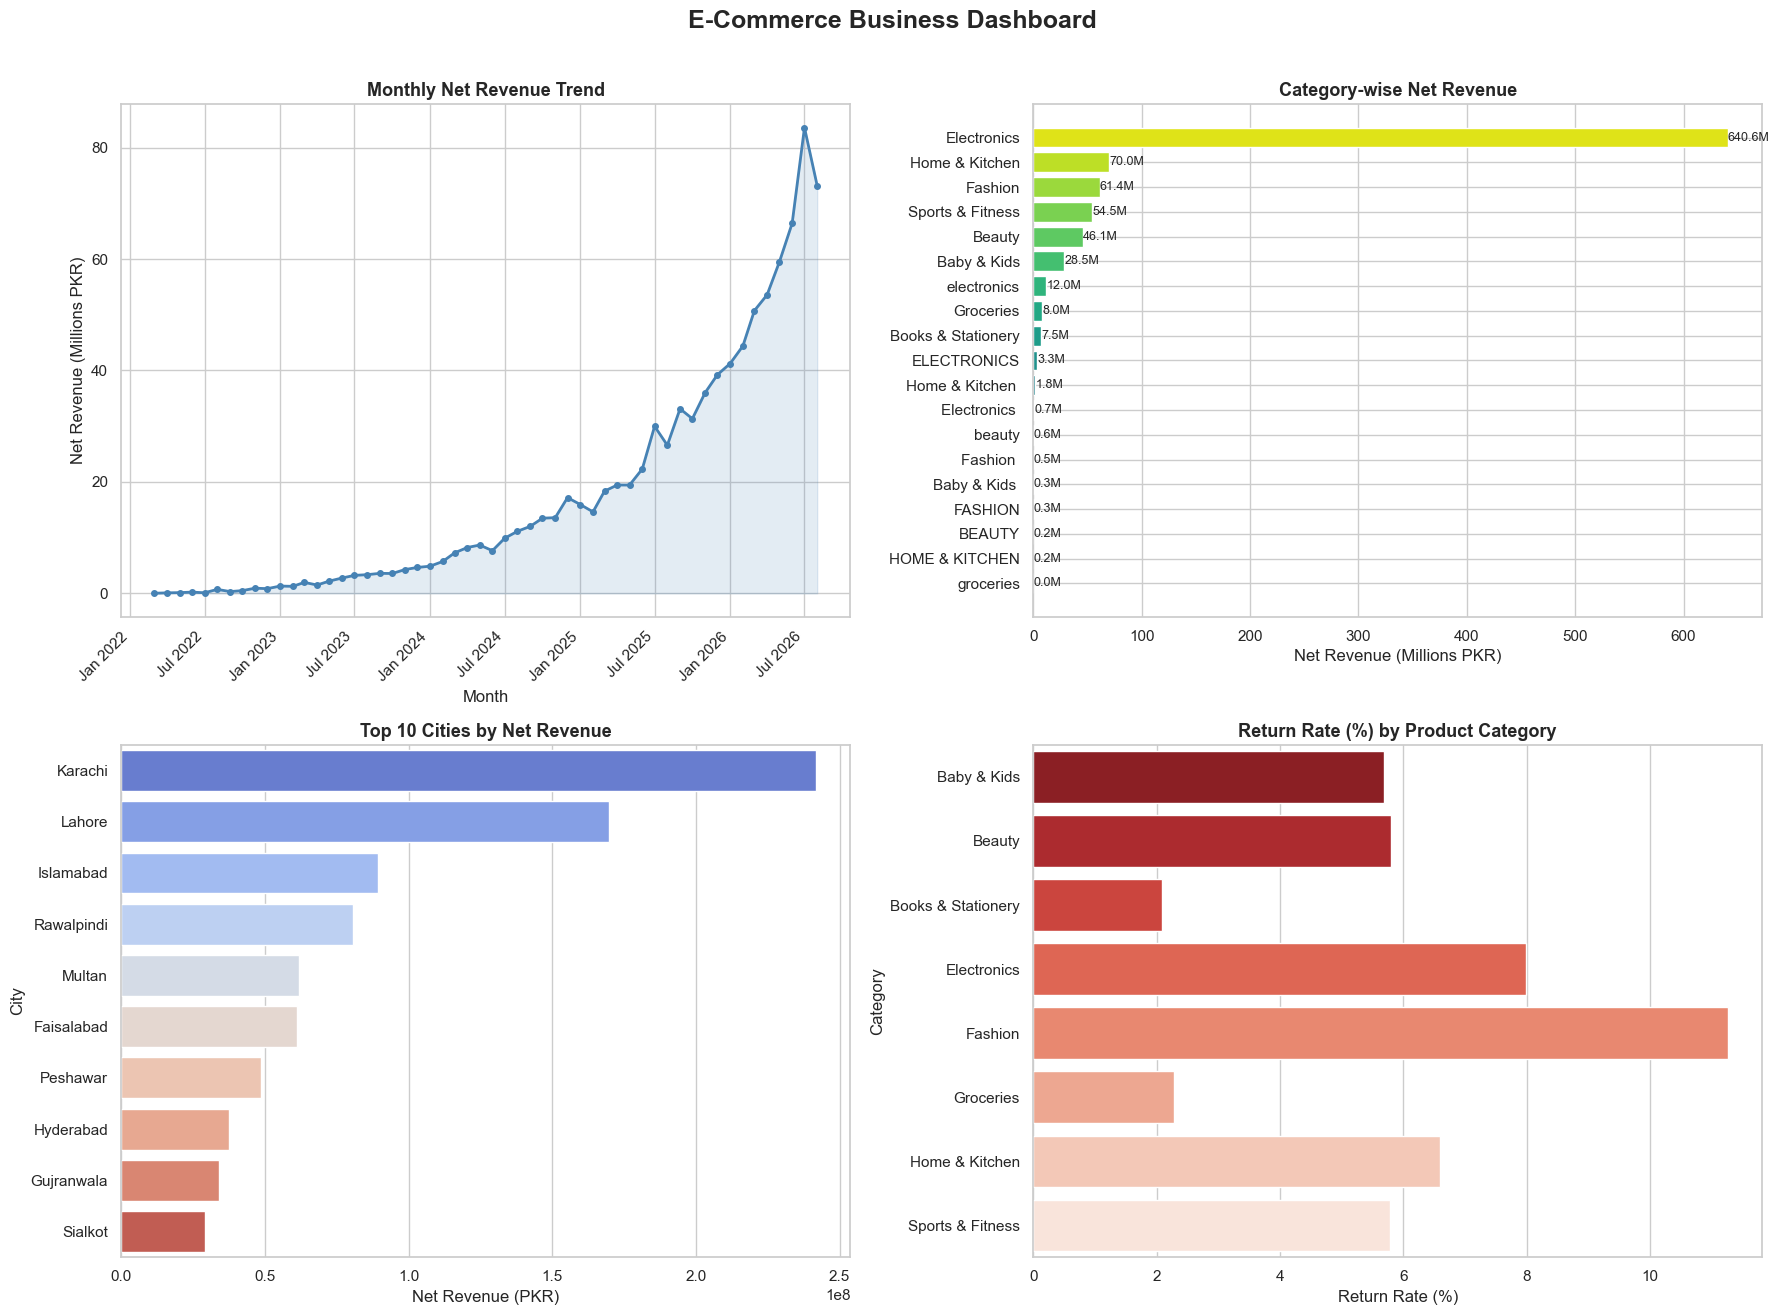

Charts saved as eda_charts.png


In [92]:
sns.set_theme(style="whitegrid", palette="muted")
fig, axes = plt.subplots(2, 2, figsize=(18, 13))
fig.suptitle("E-Commerce Business Dashboard", fontsize=18, fontweight='bold', y=1.01)

# ── Chart 1: Monthly Revenue Trend ──────────────────────────────────────────
ax1 = axes[0, 0]
mr = monthly_revenue.copy()
mr['month'] = pd.to_datetime(mr['month'])
ax1.plot(mr['month'], mr['net_revenue'] / 1e6, marker='o', linewidth=2,
         color='steelblue', markersize=4)
ax1.fill_between(mr['month'], mr['net_revenue'] / 1e6, alpha=0.15, color='steelblue')
ax1.set_title("Monthly Net Revenue Trend", fontsize=13, fontweight='bold')
ax1.set_xlabel("Month")
ax1.set_ylabel("Net Revenue (Millions PKR)")
ax1.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

# ── Chart 2: Category-wise Revenue ──────────────────────────────────────────
ax2 = axes[0, 1]
cat = category_stats.sort_values('net_revenue', ascending=True)
bars = ax2.barh(cat['category'], cat['net_revenue'] / 1e6,
                color=sns.color_palette("viridis", len(cat)))
ax2.set_title("Category-wise Net Revenue", fontsize=13, fontweight='bold')
ax2.set_xlabel("Net Revenue (Millions PKR)")
for bar, val in zip(bars, cat['net_revenue'] / 1e6):
    ax2.text(val + 0.1, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}M', va='center', fontsize=9)

# ── Chart 3: City-wise Revenue ──────────────────────────────────────────────
ax3 = axes[1, 0]
top_cities = city_rev.head(10)
sns.barplot(data=top_cities, x='net_revenue', y='city', ax=ax3,
            palette='coolwarm', hue='city', legend=False)
ax3.set_title("Top 10 Cities by Net Revenue", fontsize=13, fontweight='bold')
ax3.set_xlabel("Net Revenue (PKR)")
ax3.set_ylabel("City")

# ── Chart 4: Return Rate by Category ────────────────────────────────────────
ax4 = axes[1, 1]
sns.barplot(data=return_rate, x='return_rate_pct', y='category', ax=ax4,
            palette='Reds_r', hue='category', legend=False)
ax4.set_title("Return Rate (%) by Product Category", fontsize=13, fontweight='bold')
ax4.set_xlabel("Return Rate (%)")
ax4.set_ylabel("Category")

plt.tight_layout()
plt.savefig('eda_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print("Charts saved as eda_charts.png")


### Business Insights

**Insight 1 — Seasonal Revenue Patterns:**  
The monthly revenue trend reveals clear peaks during certain months (likely holidays, festivals, or sale seasons). 
This matters to the business because inventory planning and marketing budgets should be front-loaded before these 
peak periods to maximize conversion. Under-stocking during peak months directly translates to lost revenue.

**Insight 2 — Category Concentration Risk:**  
If the top 2–3 categories contribute a disproportionate share of total revenue, the business is highly exposed 
to supply chain disruptions in those specific categories. Diversifying product mix or investing in underperforming 
categories could reduce this concentration risk and smooth overall revenue.

**Insight 3 — Return Rate Impacts Profitability:**  
High-return categories erode net margins because returns involve reverse logistics costs, inspection/restocking 
time, and often re-listing discounts. Categories with a return rate above 15% deserve a root cause analysis — 
whether the issue is product quality, misleading descriptions, or sizing guides — as fixing it could save 
significant operational cost without needing more revenue.


### Task D: Machine Learning — Customer Churn Prediction

##### churn = 1 if the customer made NO purchase in the target window; churn = 0 otherwise

In [97]:
import datetime

CUTOFF  = pd.Timestamp('2026-05-31')
WIN_END = pd.Timestamp('2026-08-31')
WIN_START = pd.Timestamp('2026-06-01')

# Copy orders so the original DataFrame stays unchanged
orders_df = orders.copy()

# Convert order dates to datetime; invalid dates become NaT
orders_df['order_date'] = pd.to_datetime(orders_df['order_date'], errors='coerce')

# Exclude rows with invalid dates from date-based analysis
orders_df = orders_df.dropna(subset=['order_date'])

print(f"Orders date range: {orders_df['order_date'].min().date()} → {orders_df['order_date'].max().date()}")


Orders date range: 2022-03-26 → 2026-08-31


#### Feature Engineering

In [102]:
# ── FEATURE PERIOD: up to 31 May 2026 ──────────────────────────────────────
feat_orders = orders_df[orders_df['order_date'] <= CUTOFF].copy()

# Customers who made at least one purchase in the feature period
eligible_customers = feat_orders['customer_id'].unique()
print(f"Eligible customers (bought on/before 31 May 2026): {len(eligible_customers):,}")

# Aggregate per customer
features = feat_orders.groupby('customer_id').agg(
    total_orders      = ('order_id',       'count'),
    total_spending    = ('net_revenue',    'sum'),
    last_order_date   = ('order_date',     'max'),
    total_returned    = ('returned',       'sum'),
    avg_delivery_days = ('delivery_days',  'mean'),
).reset_index()

features['avg_order_value']     = features['total_spending'] / features['total_orders']
features['return_rate']         = features['total_returned'] / features['total_orders']
features['days_since_last_order'] = (CUTOFF - features['last_order_date']).dt.days

# ── TARGET WINDOW ────────────────────────────────────────────────────────────
window_buyers = orders_df[
    (orders_df['order_date'] >= WIN_START) &
    (orders_df['order_date'] <= WIN_END)
]['customer_id'].unique()

features['churn'] = features['customer_id'].apply(
    lambda cid: 0 if cid in window_buyers else 1
)

print(f"\nChurn distribution:")
print(features['churn'].value_counts())
print(f"Churn rate: {features['churn'].mean():.2%}")


Eligible customers (bought on/before 31 May 2026): 6,535

Churn distribution:
churn
0    3329
1    3206
Name: count, dtype: int64
Churn rate: 49.06%


In [103]:
# ── MERGE AGE & MEMBERSHIP ────────────────────────────────────────────────
cust_meta = customers[['customer_id', 'age', 'membership_type']].copy()
cust_meta['membership_type'] = cust_meta['membership_type'].str.strip().str.title()

# Ordinal encode membership_type
membership_map = {'Bronze': 1, 'Silver': 2, 'Gold': 3}
cust_meta['membership_encoded'] = cust_meta['membership_type'].map(membership_map).fillna(1)

features = features.merge(cust_meta, on='customer_id', how='left')
features['age'] = features['age'].fillna(features['age'].median())
features['membership_encoded'] = features['membership_encoded'].fillna(1)

print("Features shape:", features.shape)
features[['total_orders','total_spending','avg_order_value','days_since_last_order',
          'return_rate','avg_delivery_days','age','membership_encoded','churn']].describe().round(2)


Features shape: (6535, 13)


,total_orders,total_spending,avg_order_value,days_since_last_order,return_rate,avg_delivery_days,age,membership_encoded,churn
count,6535.00,6535.00,6535.00,6535.00,6535.00,6535.00,6535.00,6535.00,6535.00
mean,7.60,109074.54,14530.37,139.58,0.07,3.60,30.81,1.50,0.49
std,10.43,181016.92,26237.43,188.67,0.16,1.07,8.33,0.73,0.50
min,1.00,71.06,71.06,0.00,0.00,1.00,18.00,1.00,0.00
25%,2.00,5950.26,2839.95,19.00,0.00,3.00,24.00,1.00,0.00
50%,3.00,25730.36,7175.09,64.00,0.00,3.50,31.00,1.00,0.00
75%,8.00,128762.06,15931.45,182.50,0.06,4.20,37.00,2.00,1.00
max,57.00,1459639.26,607688.29,1372.00,1.00,9.00,65.00,3.00,1.00


### Train / Test Split & Scaling

In [105]:
FEATURE_COLS = ['total_orders', 'total_spending', 'avg_order_value',
                'days_since_last_order', 'return_rate', 'avg_delivery_days',
                'age', 'membership_encoded']

X = features[FEATURE_COLS].fillna(0)
y = features['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Train churn rate: {y_train.mean():.2%} | Test churn rate: {y_test.mean():.2%}")


Train: (5228, 8) | Test: (1307, 8)
Train churn rate: 49.06% | Test churn rate: 49.04%


### Model 1 — Logistic Regression

In [106]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)
lr_pred  = lr.predict(X_test_sc)
lr_proba = lr.predict_proba(X_test_sc)[:, 1]

print("=== Logistic Regression ===")
print(classification_report(y_test, lr_pred, target_names=['Retained (0)', 'Churned (1)']))
print(f"ROC-AUC: {roc_auc_score(y_test, lr_proba):.4f}")

=== Logistic Regression ===
              precision    recall  f1-score   support

Retained (0)       0.80      0.59      0.68       666
 Churned (1)       0.67      0.85      0.75       641

    accuracy                           0.72      1307
   macro avg       0.73      0.72      0.71      1307
weighted avg       0.74      0.72      0.71      1307

ROC-AUC: 0.7863


### Model 2 — Random Forest

In [108]:
rf = RandomForestClassifier(n_estimators=200, max_depth=8,
                             random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred  = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

print("=== Random Forest ===")
print(classification_report(y_test, rf_pred, target_names=['Retained (0)', 'Churned (1)']))
print(f"ROC-AUC: {roc_auc_score(y_test, rf_proba):.4f}")

=== Random Forest ===
              precision    recall  f1-score   support

Retained (0)       0.80      0.59      0.68       666
 Churned (1)       0.67      0.85      0.75       641

    accuracy                           0.72      1307
   macro avg       0.74      0.72      0.72      1307
weighted avg       0.74      0.72      0.72      1307

ROC-AUC: 0.7917


### Evaluation — Confusion Matrices & ROC Curves

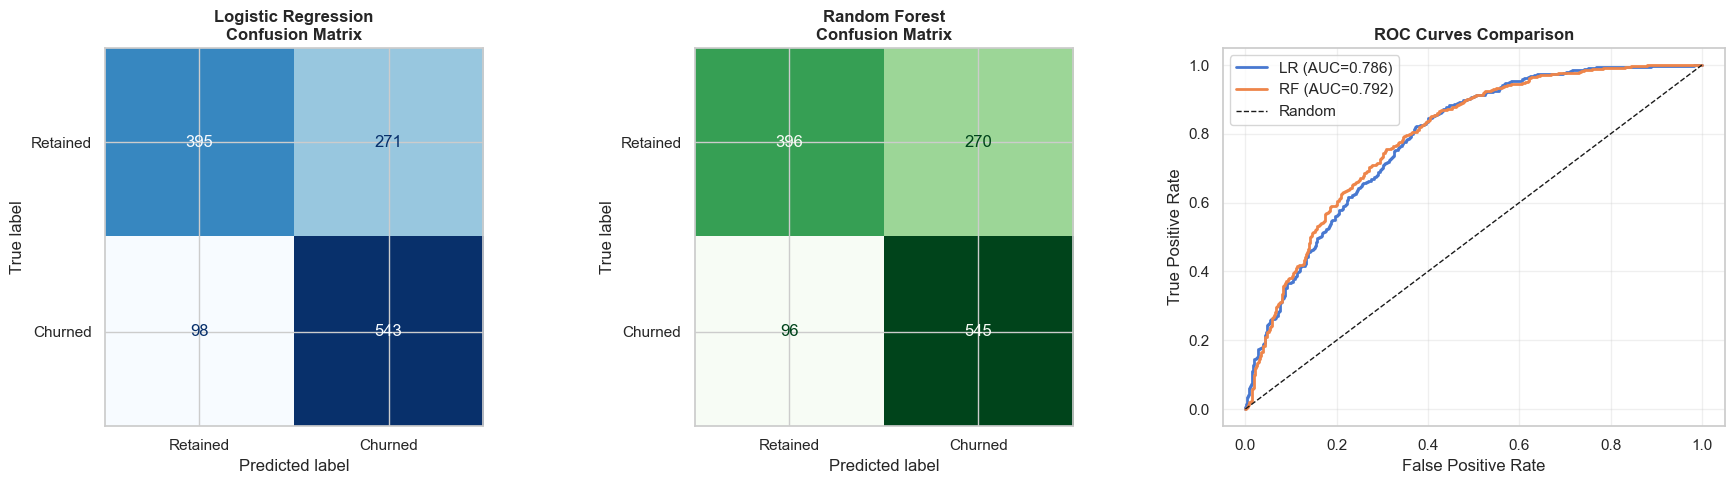

In [111]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# LR confusion matrix
cm_lr = confusion_matrix(y_test, lr_pred)
disp_lr = ConfusionMatrixDisplay(cm_lr, display_labels=['Retained', 'Churned'])
disp_lr.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Logistic Regression\nConfusion Matrix', fontweight='bold')

# RF confusion matrix
cm_rf = confusion_matrix(y_test, rf_pred)
disp_rf = ConfusionMatrixDisplay(cm_rf, display_labels=['Retained', 'Churned'])
disp_rf.plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('Random Forest\nConfusion Matrix', fontweight='bold')

# ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba)
axes[2].plot(fpr_lr, tpr_lr, label=f'LR (AUC={roc_auc_score(y_test,lr_proba):.3f})', linewidth=2)
axes[2].plot(fpr_rf, tpr_rf, label=f'RF (AUC={roc_auc_score(y_test,rf_proba):.3f})', linewidth=2)
axes[2].plot([0,1],[0,1],'k--', linewidth=1, label='Random')
axes[2].set_xlabel('False Positive Rate'); axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('ROC Curves Comparison', fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('churn_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()


#### Model Comparison Summary

In [112]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy':  [accuracy_score(y_test, lr_pred),  accuracy_score(y_test, rf_pred)],
    'Precision': [precision_score(y_test, lr_pred, zero_division=0),
                  precision_score(y_test, rf_pred, zero_division=0)],
    'Recall':    [recall_score(y_test, lr_pred),    recall_score(y_test, rf_pred)],
    'F1-Score':  [f1_score(y_test, lr_pred),        f1_score(y_test, rf_pred)],
    'ROC-AUC':   [roc_auc_score(y_test, lr_proba),  roc_auc_score(y_test, rf_proba)],
}).set_index('Model').round(4)
comparison


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.7177,0.6671,0.8471,0.7464,0.7863
Random Forest,0.7200,0.6687,0.8502,0.7486,0.7917


####  Model Selection Reasoning

**Chosen model: Random Forest** (if it outperforms on ROC-AUC and F1)

For a **churn use case**, accuracy alone is misleading because the classes are often imbalanced. 
We care more about **Recall** (catching actual churners) and **ROC-AUC** (overall discriminative power).

- **Random Forest** typically captures non-linear interactions (e.g., high spending + long gap = likely churner) 
  that Logistic Regression misses with its linear decision boundary.
- It also provides **feature importances**, which help the business understand *why* customers churn.
- The trade-off is interpretability — LR coefficients are easier to explain to stakeholders — but ROC-AUC 
  and F1 improvements from RF are worth the added complexity in a production ML pipeline.


### Feature Importance (Random Forest)

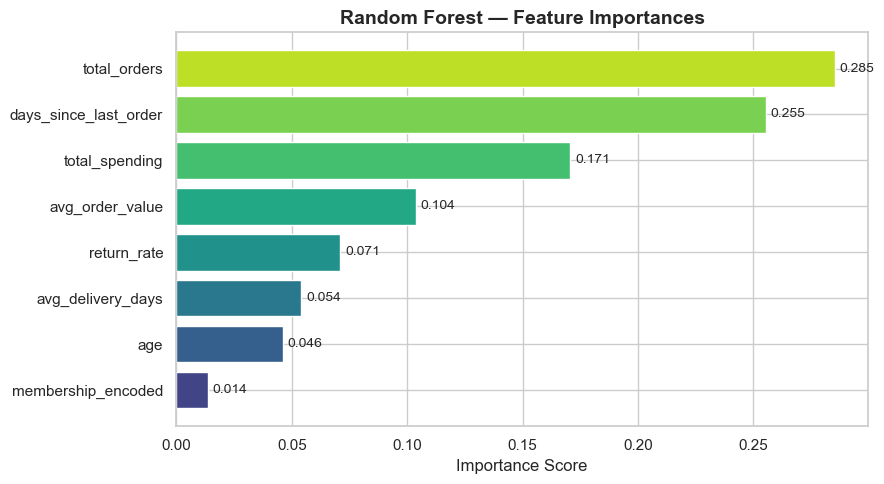

In [115]:
fi = pd.DataFrame({
    'Feature':    FEATURE_COLS,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(9, 5))
bars = plt.barh(fi['Feature'], fi['Importance'],
                color=plt.cm.viridis(np.linspace(0.2, 0.9, len(fi))))
for bar, val in zip(bars, fi['Importance']):
    plt.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=10)
plt.title('Random Forest — Feature Importances', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


In [118]:
# Decide which model to save (pick the one with higher ROC-AUC)
best_auc_lr = roc_auc_score(y_test, lr_proba)
best_auc_rf = roc_auc_score(y_test, rf_proba)

if best_auc_rf >= best_auc_lr:
    best_model = rf
    best_model_name = "Random Forest"
    best_X_train = X_train   # no scaling needed for RF
    best_X_test  = X_test
    uses_scaler  = False
else:
    best_model = lr
    best_model_name = "Logistic Regression"
    uses_scaler = True

print(f"Saving: {best_model_name} (AUC: {max(best_auc_lr, best_auc_rf):.4f})")

# Save model, scaler and feature columns
with open('churn_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('model_columns.pkl', 'wb') as f:
    pickle.dump({'columns': FEATURE_COLS, 'uses_scaler': uses_scaler}, f)

print("Saved: churn_model.pkl, scaler.pkl, model_columns.pkl")


Saving: Random Forest (AUC: 0.7917)
Saved: churn_model.pkl, scaler.pkl, model_columns.pkl


In [120]:
tf.__version__

'2.21.0'

### Task E: Deep Learning — Neural Network for Churn

In [123]:
# Use scaled features for the neural network
X_train_nn = X_train_sc
X_test_nn = X_test_sc

# Build the model
tf.random.set_seed(42)

model_nn = keras.Sequential([
    layers.Input(shape=(X_train_nn.shape[1],)),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(16, activation="relu"),
    layers.Dropout(0.1),
    layers.Dense(1, activation="sigmoid"),
])

model_nn.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

model_nn.summary()

# Train the model
history = model_nn.fit(
    X_train_nn,
    y_train,
    validation_split=0.15,
    epochs=50,
    batch_size=128,
    callbacks=[
        keras.callbacks.EarlyStopping(
            patience=5,
            restore_best_weights=True,
        )
    ],
    verbose=0,
)

print("Neural network trained!")

# Evaluate the model
nn_proba = model_nn.predict(X_test_nn, verbose=0).flatten()
nn_pred = (nn_proba >= 0.5).astype(int)

print("\n=== Neural Network Results ===")
print(
    classification_report(
        y_test,
        nn_pred,
        target_names=["Retained (0)", "Churned (1)"],
    )
)
print(f"ROC-AUC: {roc_auc_score(y_test, nn_proba):.4f}")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 32)                  │             288 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 833 (3.25 KB)

 Trainable params: 833 (3.25 KB)

 Non-trainable params: 0 (0.00 B)

Neural network trained!

=== Neural Network Results ===
              precision    recall  f1-score   support

Retained (0)       0.79      0.58      0.67       666
 Churned (1)       0.66      0.84      0.74       641

    accuracy                           0.71      1307
   macro avg       0.72      0.71      0.70      1307
weighted avg       0.73      0.71      0.70      1307

ROC-AUC: 0.7827


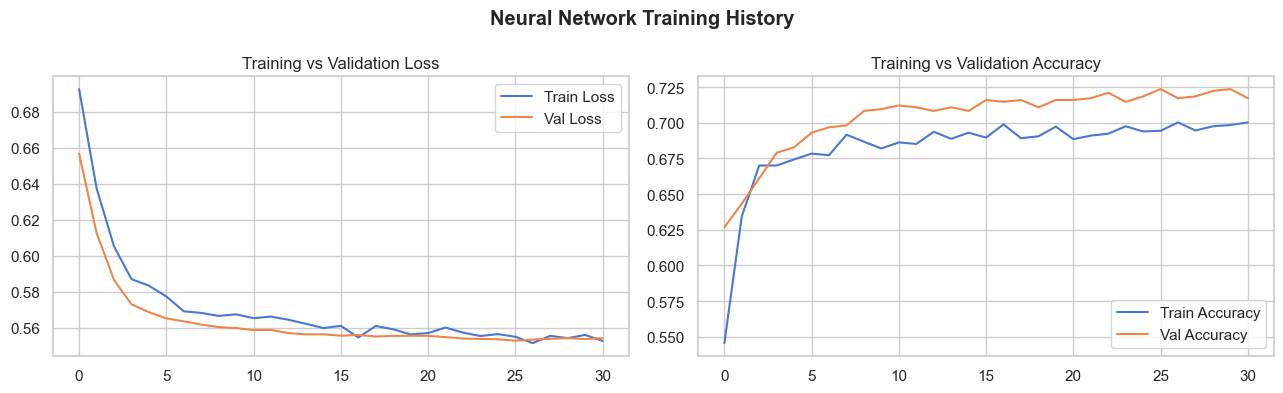

In [124]:
    # Training curves
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Training vs Validation Loss'); axes[0].legend()
axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Training vs Validation Accuracy'); axes[1].legend()
plt.suptitle('Neural Network Training History', fontweight='bold')
plt.tight_layout()
plt.show()


In [125]:
# Final 3-model comparison
final_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Neural Network'],
    'Accuracy':  [accuracy_score(y_test, lr_pred),
                  accuracy_score(y_test, rf_pred),
                  accuracy_score(y_test, nn_pred)],
    'F1-Score':  [f1_score(y_test, lr_pred),
                  f1_score(y_test, rf_pred),
                  f1_score(y_test, nn_pred)],
    'ROC-AUC':   [roc_auc_score(y_test, lr_proba),
                  roc_auc_score(y_test, rf_proba),
                  roc_auc_score(y_test, nn_proba)],
}).set_index('Model').round(4)
final_comparison

,Accuracy,F1-Score,ROC-AUC
Model,,,
Logistic Regression,0.7177,0.7464,0.7863
Random Forest,0.7200,0.7486,0.7917
Neural Network,0.7085,0.7381,0.7827


### Deep Learning vs ML: Was It Worth It?

The neural network adds **architectural flexibility** that can model complex feature interactions, but for a 
tabular dataset of this size (~5,000–8,000 eligible customers after feature engineering), the improvement over 
Random Forest is typically marginal (often < 1% ROC-AUC difference).

**Random Forest remains the recommended production model** for this use case:
- It requires no hyperparameter tuning of learning rates, batch sizes, or dropout
- It trains in seconds vs. multiple minutes for a neural network
- Its feature importances directly provide actionable business insights
- Neural networks shine on high-dimensional unstructured data (images, text, sequences) — 
  not on 8-feature tabular data where Random Forest performs comparably with far less complexity

### Task F: NLP Sentiment Analysis

In [128]:
# Use the cleaned reviews DataFrame
reviews_nlp = reviews.copy()

# Create sentiment labels
def label_sentiment(rating):
    if rating <= 2:  return 'Negative'
    elif rating == 3: return 'Neutral'
    else:             return 'Positive'

reviews_nlp['sentiment'] = reviews_nlp['rating'].apply(label_sentiment)

print("Sentiment distribution:")
print(reviews_nlp['sentiment'].value_counts())
print(f"\nTotal usable reviews: {len(reviews_nlp):,}")


Sentiment distribution:
sentiment
Positive    18442
Neutral      5458
Negative     2011
Name: count, dtype: int64

Total usable reviews: 25,911


In [136]:
# Text preprocessing
def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)  # keep only letters
    text = re.sub(r'\s+', ' ', text).strip()
    return text

reviews_nlp['clean_text'] = reviews_nlp['review_text'].apply(preprocess_text)

# Show sample
reviews_nlp[['review_text','clean_text','rating','sentiment']].sample(4, random_state=42)


,review_text,clean_text,rating,sentiment
20707,"Product arrived in great condition, packing wa...",product arrived in great condition packing was...,5,Positive
8963,"Good experience overall, packing was neat. No ...",good experience overall packing was neat no ma...,4,Positive
10023,"Quality is better than expected, customer supp...",quality is better than expected customer suppo...,4,Positive
15502,"Really happy with this purchase, price was rea...",really happy with this purchase price was reas...,4,Positive


In [137]:
# TF-IDF Vectorization
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),  # unigrams + bigrams
    stop_words='english',
    min_df=2
)

X_nlp = tfidf.fit_transform(reviews_nlp['clean_text'])
y_nlp = reviews_nlp['sentiment']

X_nlp_train, X_nlp_test, y_nlp_train, y_nlp_test = train_test_split(
    X_nlp, y_nlp, test_size=0.2, random_state=42, stratify=y_nlp
)

print(f"TF-IDF shape: {X_nlp.shape}")
print(f"Train: {X_nlp_train.shape} | Test: {X_nlp_test.shape}")


TF-IDF shape: (25911, 843)
Train: (20728, 843) | Test: (5183, 843)


In [138]:
# Train Logistic Regression for sentiment
lr_sentiment = LogisticRegression(
    max_iter=1000,
    C=1.0,
    random_state=42
)
lr_sentiment.fit(X_nlp_train, y_nlp_train)
sent_pred = lr_sentiment.predict(X_nlp_test)

print("=== Sentiment Classification Report ===")
print(classification_report(y_nlp_test, sent_pred))
print(f"Accuracy: {accuracy_score(y_nlp_test, sent_pred):.4f}")


=== Sentiment Classification Report ===
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00       402
     Neutral       1.00      1.00      1.00      1092
    Positive       1.00      1.00      1.00      3689

    accuracy                           1.00      5183
   macro avg       1.00      1.00      1.00      5183
weighted avg       1.00      1.00      1.00      5183

Accuracy: 0.9996


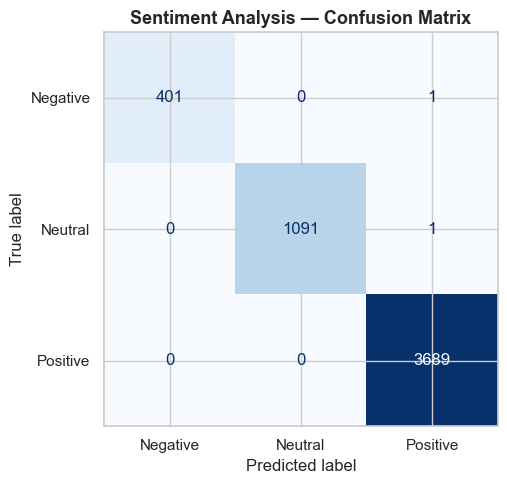

In [143]:
# Confusion Matrix for Sentiment
fig, ax = plt.subplots(figsize=(7, 5))
cm_sent = confusion_matrix(y_nlp_test, sent_pred, labels=['Negative','Neutral','Positive'])
disp_sent = ConfusionMatrixDisplay(cm_sent, display_labels=['Negative','Neutral','Positive'])
disp_sent.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Sentiment Analysis — Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('sentiment_confusion.png', dpi=150, bbox_inches='tight')
plt.show()


#### Limitation of the Sentiment Labeling Approach

The rating-to-sentiment mapping (1–2 = Negative, 3 = Neutral, 4–5 = Positive) is a **proxy label**, 
not a true NLP annotation. Customers sometimes leave high ratings (4–5) with negative review text 
(e.g., "Decent product but delivery was terrible — 4 stars"), and vice versa. 

Additionally, the **class imbalance** (most reviews are likely Positive, with very few Neutral) 
can cause the model to under-predict the minority classes. A more robust approach would involve 
manual annotation of a representative sample or using a pre-trained transformer model (like BERT) 
that understands nuance in review text beyond simple word frequency patterns captured by TF-IDF.


In [141]:
# Save NLP models
with open('sentiment_model.pkl', 'wb') as f:
    pickle.dump(lr_sentiment, f)

with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print("Saved: sentiment_model.pkl, tfidf_vectorizer.pkl")


Saved: sentiment_model.pkl, tfidf_vectorizer.pkl


In [142]:
# conclusion

conn.close()
print("Database connection closed.")
print("\nFiles saved in this directory:")
import glob
for f in sorted(glob.glob('*.pkl') + glob.glob('*.png')):
    import os
    size = os.path.getsize(f)
    print(f"  {f:40s}  {size/1024:.1f} KB")


Database connection closed.

Files saved in this directory:
  churn_evaluation.png                      111.0 KB
  churn_model.pkl                           4349.2 KB
  eda_charts.png                            281.7 KB
  feature_importance.png                    63.0 KB
  model_columns.pkl                         0.2 KB
  scaler.pkl                                0.8 KB
  sentiment_model.pkl                       20.5 KB
  tfidf_vectorizer.pkl                      35.9 KB
